# Mini-TP 5 — Federa tu modelo y mide el trade-off

Operaciones de Aprendizaje Automático II · CEIA – FIUBA · Entrega individual

Entrena el modelo sin juntar los datos: cada cliente entrena con lo suyo y solo comparte los pesos. Se compara contra el modelo centralizado, con los datos repartidos al azar y por zona de la ciudad, y se mide qué cuesta agregar privacidad.

## Qué se entrega

1. La muestra repartida entre K clientes y una simulación con FedAvg.
2. La comparación entre la accuracy federada y la centralizada.
3. La partición non-IID y el gráfico de accuracy por ronda.
4. El análisis del trade-off entre privacidad y performance.
5. El agregado de ruido, que es la parte opcional.

Como en los TPs anteriores, los `.py` de `tp5_federated/` son la fuente y están cubiertos por tests; el notebook los importa y los muestra.

In [1]:
import os
from pathlib import Path

import arrest_model

# El notebook vive en tp5_federated/, pero los imports esperan la raíz del repo.
REPO = Path(arrest_model.__file__).resolve().parent.parent
os.chdir(REPO)
print("listo, desde", REPO)

listo, desde /Users/belcattaneo/Documents/MIA/MLOPS2/mlops2-minitps


## 1. Los datos y el modelo

La muestra son 20.000 filas del dataset del TP-final, con las mismas 7 features que consumen las APIs del repo y la etiqueta de arresto. Se versiona la muestra y no el dataset completo, que tiene casi 200.000 filas.

El modelo que se federa es una regresión logística, no el XGBoost que sirve el repo: FedAvg promedia los pesos de los modelos locales, y un ensamble de árboles no tiene pesos que promediar. Las features son las mismas; lo que cambia es el modelo.

In [2]:
from tp5_federated.data import load_sample, train_test

muestra = load_sample()
x_train, x_test, y_train, y_test = train_test()
print(f"{len(muestra)} filas | {x_train.shape[1]} features | arrestos: {muestra['Arrest_tag'].mean():.3f}")
print(f"entrenamiento: {len(y_train)} | evaluación: {len(y_test)}")

20000 filas | 7 features | arrestos: 0.444
entrenamiento: 15000 | evaluación: 5000


## 2. Centralizado, la línea de base

Es el modelo entrenado con todos los datos juntos: lo que se lograría si no hubiera ninguna restricción para moverlos.

In [3]:
from tp5_federated.model import accuracy, train

centralizado = train(x_train, y_train)
acc_central = accuracy(centralizado, x_test, y_test)
print(f"accuracy centralizada: {acc_central:.4f}")

accuracy centralizada: 0.6388


## 3. FedAvg

Cada ronda: el servidor manda los pesos a una parte de los clientes, cada uno entrena con sus datos, y el servidor promedia lo que recibe pesando a cada cliente por su cantidad de filas. Los datos nunca se mueven.

In [4]:
from IPython.display import Code, display

display(Code(filename="tp5_federated/federated.py", language="python"))

"""Mini-TP 5: FedAvg, el promedio de los modelos de cada cliente.

Lo único que viaja del cliente al servidor son los pesos y cuántos datos los entrenaron. Los
datos no se mueven: esa es toda la idea del aprendizaje federado.
"""

from collections.abc import Callable, Sequence
from typing import NamedTuple

import numpy as np

from tp5_federated.model import LEARNING_RATE, Weights, accuracy, initial_weights, train
from tp5_federated.partitions import Client

LOCAL_EPOCHS = 25
ROUNDS = 20
# Fracción de clientes que participa de cada ronda: en un sistema real no están todos siempre.
FRACTION = 0.6


class Update(NamedTuple):
    """Lo que un cliente le manda al servidor: su modelo y cuántos datos lo entrenaron."""

    weights: Weights
    samples: int


def local_update(
    global_weights: Weights,
    client: Client,
    epochs: int = LOCAL_EPOCHS,
    lr: float = LEARNING_RATE,
) -> Update:
    """Entrena el modelo global con los datos del cliente y devuelve solo los pesos."""
    weights = train(client.x, client.y, epochs=epochs, lr=lr, start=global_weights)
    return Update(weights, samples=len(client.y))


def aggregate(updates: Sequence[Update]) -> Weights:
    """Promedia los modelos recibidos, pesando a cada cliente por su cantidad de datos.

    Sin esa ponderación, un cliente con cien filas movería el modelo global tanto como uno con
    cien mil.
    """
    total = sum(update.samples for update in updates)
    w = sum(update.weights.w * (update.samples / total) for update in updates)
    b = sum(update.weights.b * (update.samples / total) for update in updates)
    return Weights(np.asarray(w), float(b))


def run_rounds(
    clients: Sequence[Client],
    x_test: np.ndarray,
    y_test: np.ndarray,
    *,
    rounds: int = ROUNDS,
    fraction: float = FRACTION,
    epochs: int = LOCAL_EPOCHS,
    seed: int = 0,
    aggregator: Callable[[Sequence[Update]], Weights] = aggregate,
) -> list[float]:
    """Corre las rondas y devuelve la accuracy del modelo global después de cada una.

    En cada ronda participa solo una fracción de los clientes, como en un sistema real, donde no
    todos están disponibles siempre. El agregador entra por parámetro para poder cambiarlo por
    uno que agregue ruido sin tocar el bucle.
    """
    rng = np.random.default_rng(seed)
    elegidos = max(1, round(fraction * len(clients)))
    weights = initial_weights(x_test.shape[1])
    history = []
    for _ in range(rounds):
        ronda = rng.choice(len(clients), elegidos, replace=False)
        weights = aggregator([local_update(weights, clients[i], epochs) for i in ronda])
        history.append(accuracy(weights, x_test, y_test))
    return history

## 4. Las particiones: al azar y por zona

Repartir al azar es el caso fácil: cada cliente ve una muestra parecida al total. Repartir por zona es el realista, donde cada cliente tiene los reportes de una franja de la ciudad, y también el difícil: los modelos locales aprenden de poblaciones distintas.

In [5]:
from arrest_model.features import MODEL_FEATURES
from tp5_federated.partitions import by_zone, iid

norte_sur = MODEL_FEATURES.index("Y Coordinate_standardized")
for nombre, clientes in [("al azar", iid(x_train, y_train)), ("por zona", by_zone(x_train, y_train))]:
    print(f"--- {nombre} ---")
    for i, c in enumerate(clientes, 1):
        print(f"  cliente {i}: {len(c.y)} filas | arrestos {c.y.mean():.3f} | norte-sur medio {c.x[:, norte_sur].mean():+.2f}")

--- al azar ---
  cliente 1: 3000 filas | arrestos 0.437 | norte-sur medio -0.01
  cliente 2: 3000 filas | arrestos 0.452 | norte-sur medio +0.03
  cliente 3: 3000 filas | arrestos 0.457 | norte-sur medio +0.00
  cliente 4: 3000 filas | arrestos 0.439 | norte-sur medio -0.00
  cliente 5: 3000 filas | arrestos 0.438 | norte-sur medio -0.01
--- por zona ---
  cliente 1: 3000 filas | arrestos 0.411 | norte-sur medio -1.43
  cliente 2: 3000 filas | arrestos 0.434 | norte-sur medio -0.69
  cliente 3: 3000 filas | arrestos 0.509 | norte-sur medio +0.19
  cliente 4: 3000 filas | arrestos 0.488 | norte-sur medio +0.59
  cliente 5: 3000 filas | arrestos 0.380 | norte-sur medio +1.34


Repartir por zona no solo separa la geografía: arrastra también la etiqueta, porque en unas zonas se arresta más que en otras. Eso es lo que le cuesta al promedio.

## 5. Accuracy por ronda

In [6]:
from tp5_federated.federated import run_rounds

hist_iid = run_rounds(iid(x_train, y_train), x_test, y_test)
hist_zona = run_rounds(by_zone(x_train, y_train), x_test, y_test)
print(f"centralizado {acc_central:.4f} | IID {hist_iid[-1]:.4f} | por zona {hist_zona[-1]:.4f}")

centralizado 0.6388 | IID 0.6388 | por zona 0.6300


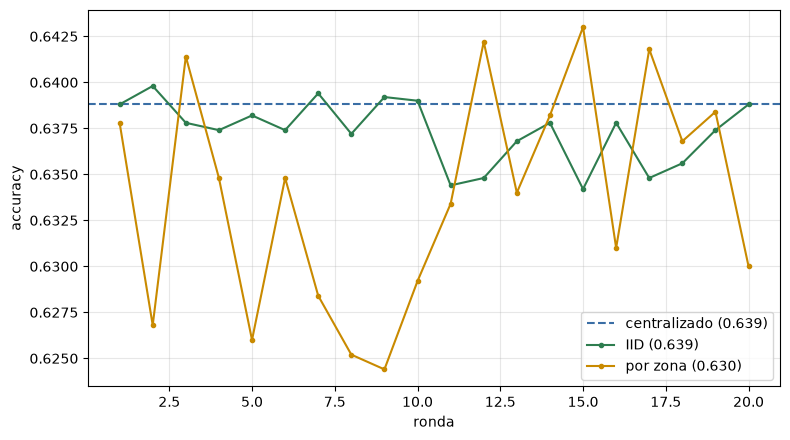

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.axhline(acc_central, ls="--", color="#3A6EA5", label=f"centralizado ({acc_central:.3f})")
plt.plot(range(1, len(hist_iid) + 1), hist_iid, "-o", ms=3, color="#2E7D4F", label=f"IID ({hist_iid[-1]:.3f})")
plt.plot(range(1, len(hist_zona) + 1), hist_zona, "-o", ms=3, color="#C98A00", label=f"por zona ({hist_zona[-1]:.3f})")
plt.xlabel("ronda"); plt.ylabel("accuracy"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

La curva IID se pega a la línea del centralizado desde la primera ronda. La de zonas queda por debajo y oscila: cada ronda promedia un conjunto distinto de clientes, y como cada uno aprendió de una población distinta, el resultado se mueve.

## 6. El costo de la privacidad

Que los datos no se muevan no alcanza para decir que son privados: los pesos que manda cada cliente llevan información sobre las filas que los entrenaron. Sumarle ruido al promedio la desdibuja, y cuesta accuracy.

In [8]:
from tp5_federated.run import privacy_cost

for sigma, valor in privacy_cost().items():
    print(f"sigma {sigma:<5} -> accuracy {valor:.4f}")

sigma 0.0   -> accuracy 0.6388
sigma 0.05  -> accuracy 0.6388
sigma 0.1   -> accuracy 0.6354
sigma 0.2   -> accuracy 0.6268
sigma 0.5   -> accuracy 0.6084


### Reflexión

> Pendiente de completar: cuánto cuesta federar, la estabilidad de la curva por zonas, qué privacidad agregaría y si el federado es orgánico o forzado.